In [25]:
# Importation des bibliothèques nécessaires
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense, Conv2DTranspose, Reshape, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [26]:


# Chargement du dataset CIFAR-10
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

# Normalisation et redimensionnement des images
def preprocess_images(images):
    images = images.astype('float32') / 255.0
    return images

x_train = preprocess_images(x_train)
x_test = preprocess_images(x_test)

print("Forme des données d'entraînement :", x_train.shape)
print("Forme des données de test :", x_test.shape)

Forme des données d'entraînement : (50000, 32, 32, 3)
Forme des données de test : (10000, 32, 32, 3)


In [27]:
# Fonction pour ajouter du bruit gaussien
def add_gaussian_noise(images, noise_factor=0.025):
    noisy_images = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy_images = np.clip(noisy_images, 0., 1.)
    return noisy_images

# Création des images de test bruitées
x_test_noisy = add_gaussian_noise(x_test, noise_factor=0.025)

print("Forme des données de test bruitées :", x_test_noisy.shape)

Forme des données de test bruitées : (10000, 32, 32, 3)


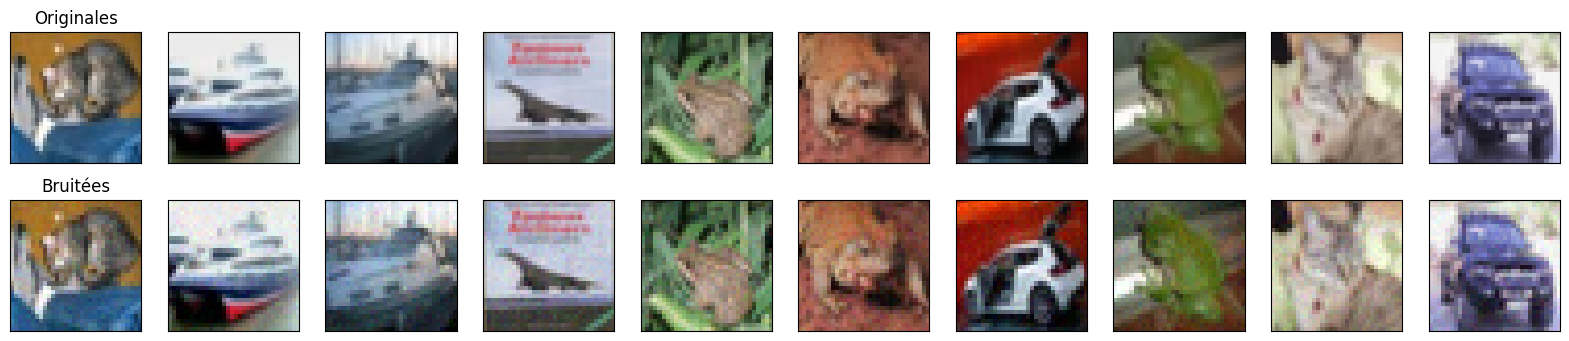

In [28]:

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Image originale
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Originales")

    # Image bruitée
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Bruitées")
plt.show()

In [ ]:
from tensorflow.keras import layers, Model, Input
from tensorflow.keras import backend as K
import tensorflow as tf

# --- 1. Paramètres du modèle ---
latent_dim = 128
kl_weight = 0.005

# --- 2. Fonction d'échantillonnage (inchangée) ---
def sampling(args):
    z_mean, z_log_var = args
    batch = K.shape(z_mean)[0]
    dim = K.int_shape(z_mean)[1]
    epsilon = K.random_normal(shape=(batch, dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

# --- 3. La classe VAE complète ---
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            
            # Application du poids sur la perte KL
            total_loss = reconstruction_loss + kl_weight * kl_loss
            
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)
            )
        )
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

        total_loss = reconstruction_loss + kl_weight * kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {m.name: m.result() for m in self.metrics}

# --- 4. Définition de l'architecture (avec capacité augmentée) ---

# Encodeur
encoder_inputs = Input(shape=(32, 32, 3))
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(128, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x) # Ajout d'une couche Dense
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = layers.Lambda(sampling, name='z')([z_mean, z_log_var])
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

# Décodeur
latent_inputs = Input(shape=(latent_dim,))
x = layers.Dense(8 * 8 * 128, activation="relu")(latent_inputs) # Ajusté à la nouvelle capacité
x = layers.Reshape((8, 8, 128))(x)
x = layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
decoder = Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

# --- 5. Instanciation et compilation ---
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005))

print("\nLe modèle VAE est prêt à être entraîné !")

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 16, 16,    │      1,792 │ input_layer_10[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 8, 8, 128) │     73,856 │ conv2d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 8192)      │          0 │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 128)       │  1,048,704 │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 64)        │      8,256 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 64)        │      8,256 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 64)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,140,864 (4.35 MB)

 Trainable params: 1,140,864 (4.35 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 8192)           │       532,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_7 (Reshape)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_21             │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_22             │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_23             │ (None, 32, 32, 3)      │         1,731 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 755,587 (2.88 MB)

 Trainable params: 755,587 (2.88 MB)

 Non-trainable params: 0 (0.00 B)


Le modèle VAE est prêt à être entraîné !


In [34]:
# Cellule d'entraînement
history = vae.fit(x_train, # Plus besoin de répéter x_train en cible
                  epochs=30,
                  batch_size=32,
                  validation_data=x_test) # On passe juste x_test pour la validation

Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 44ms/step - kl_loss: 182.6458 - reconstruction_loss: 610.0266 - total_loss: 610.9393 - val_kl_loss: 199.4563 - val_reconstruction_loss: 594.8536 - val_total_loss: 595.8507
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - kl_loss: 202.0074 - reconstruction_loss: 590.9570 - total_loss: 591.9672 - val_kl_loss: 202.8696 - val_reconstruction_loss: 590.3304 - val_total_loss: 591.3450
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - kl_loss: 202.3335 - reconstruction_loss: 588.2294 - total_loss: 589.2406 - val_kl_loss: 198.4314 - val_reconstruction_loss: 588.2251 - val_total_loss: 589.2172
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - kl_loss: 200.6472 - reconstruction_loss: 586.9310 - total_loss: 587.9346 - val_kl_loss: 200.6067 - val_reconstruction_loss: 587.6835 - val_total_loss: 588.6867
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - kl_loss: 198.1510 - reconstruction_loss: 586.4482 - total_loss: 587.43

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


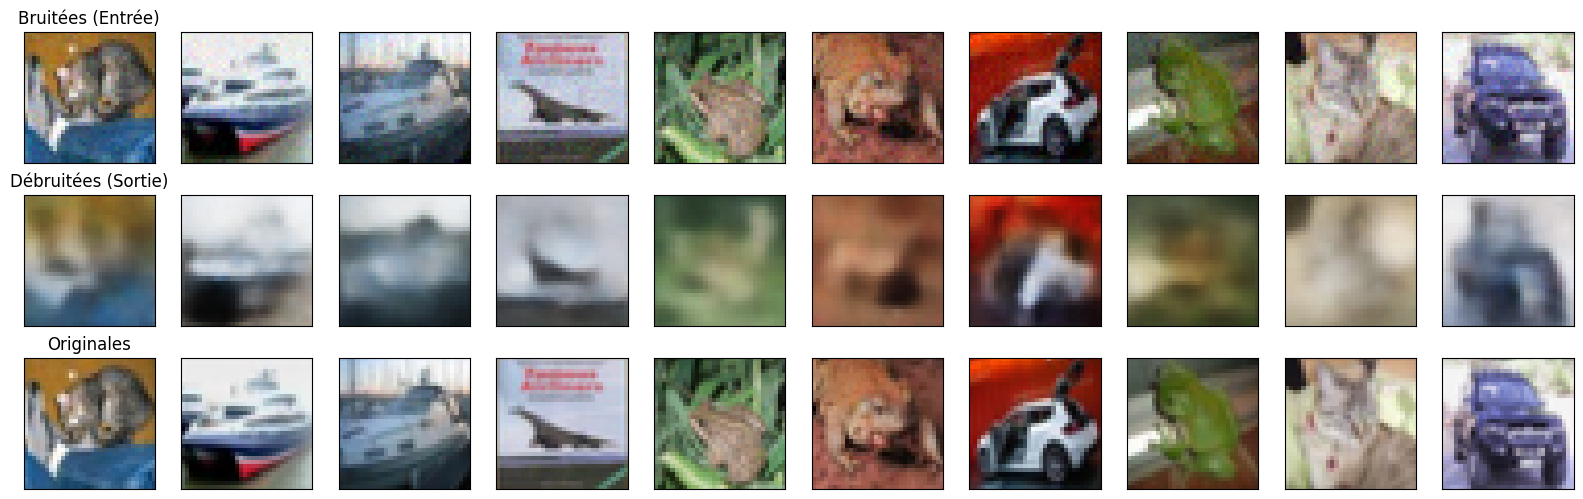

In [35]:

denoised_images = vae.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Bruitée
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i])
    ax.get_xaxis().set_visible(False); ax.get_yaxis().set_visible(False)
    if i == 0: ax.set_title("Bruitées (Entrée)")

    # Débruitée
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[i])
    ax.get_xaxis().set_visible(False); ax.get_yaxis().set_visible(False)
    if i == 0: ax.set_title("Débruitées (Sortie)")

    # Originale
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(x_test[i])
    ax.get_xaxis().set_visible(False); ax.get_yaxis().set_visible(False)
    if i == 0: ax.set_title("Originales")

plt.show()